# Random Forest Deep Dive: Bagging & Feature Importance
**Tujuan:**
1. Memahami perbedaan antara *Single Decision Tree* dan *Random Forest*.
2. Menganalisis *Feature Importance* untuk seleksi fitur.
3. Melakukan tuning `n_estimators` untuk mencari *sweet spot* antara akurasi dan waktu komputasi.

In [1]:
"""
WEEK 4 DAY 1 : RANDOM FOREST
Bagging & Feature Importance.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [2]:
# ── 1. BUAT DATASET SINTETIS ──────────────────────────────────────────
# make_classification: bikin dataset klasifikasi dengan noise
X, y = make_classification(
    n_samples=2000,       # jumlah baris
    n_features=15,        # total fitur
    n_informative=8,      # fitur yang benar-benar relevan
    n_redundant=4,        # fitur turunan dari informative
    n_repeated=0,
    random_state=42
)


#make_classification dengan n_informative=8 dari 15 fitur → kita tahu ground truth fitur mana yang relevan. Nanti kita bisa cek apakah RandomForest berhasil menemukan 8 fitur itu.


In [3]:
# Beri nama fitur supaya feature importance lebih mudah dibaca
feature_names = [f"feature_{i:02d}" for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)

In [4]:
# ── 2. SPLIT ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y           #stratify=y di train-test split → penting kalau class imbalanced. Tanpa ini, bisa dapat split yang kebetulan punya distribusi class berbeda.
)

In [5]:
# ── 3. BASELINE: SINGLE DECISION TREE ────────────────────────────────
dt = DecisionTreeClassifier(random_state=42)
# Tidak dibatasi depth → bisa overfit sempurna ke training data
dt.fit(X_train, y_train)

dt_train_score = dt.score(X_train, y_train)   # accuracy di training
dt_test_score  = dt.score(X_test, y_test)     # accuracy di test
dt_auc         = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])

print(f"Decision Tree | Train acc: {dt_train_score:.3f} | Test acc: {dt_test_score:.3f} | AUC: {dt_auc:.3f}")
# Kamu akan lihat train acc mendekati 1.0 → tanda overfit

Decision Tree | Train acc: 1.000 | Test acc: 0.797 | AUC: 0.797


In [6]:
# ── 4. RANDOM FOREST ─────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,    # jumlah tree (start dari 100, kita analisa nanti)
    max_features="sqrt", # max_features="sqrt" → ini yang membuat RandomForest random. Setiap split, hanya √15 ≈ 4 fitur yang dipertimbangkan. Kalau diisi None atau 1.0, semua fitur dipakai → tidak ada randomness → performanya mendekati Bagging biasa, bukan RandomForest.
    random_state=42,
    n_jobs=-1            # pakai semua CPU core
)
rf.fit(X_train, y_train)

rf_train_score = rf.score(X_train, y_train) 
rf_test_score  = rf.score(X_test, y_test)
rf_auc         = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(f"Random Forest | Train acc: {rf_train_score:.3f} | Test acc: {rf_test_score:.3f} | AUC: {rf_auc:.3f}")

Random Forest | Train acc: 1.000 | Test acc: 0.890 | AUC: 0.952


In [7]:
# ── 5. FEATURE IMPORTANCE ────────────────────────────────────────────
importances = rf.feature_importances_
# feature_importances_ → array panjang n_features, total = 1.0

In [8]:
# Sort dari tertinggi ke terendah
fi_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

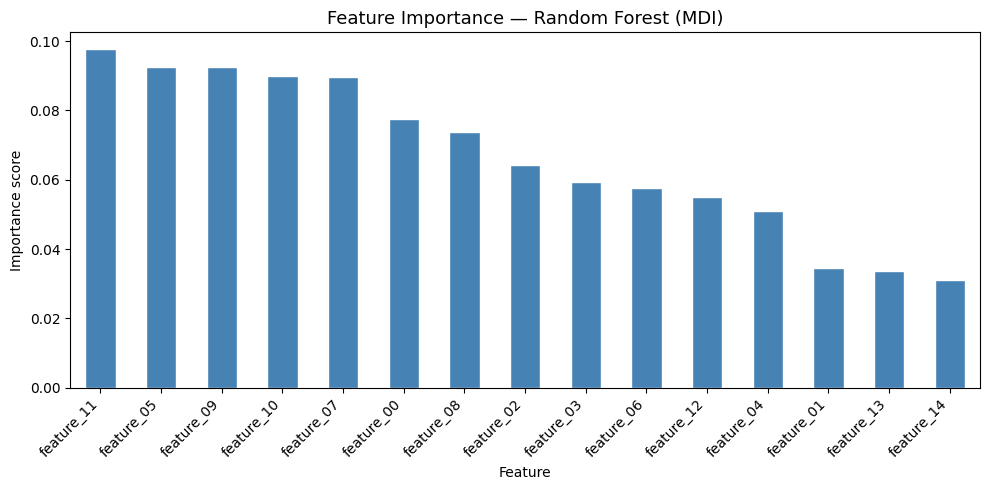

In [9]:
# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
fi_series.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Feature Importance — Random Forest (MDI)", fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("Importance score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
# ── 6. ANALISA DAMPAK n_estimators ───────────────────────────────────
n_est_list = [1, 5, 10, 25, 50, 100, 200, 500]
results = []

for n in n_est_list:
    start = time.time()
    model = RandomForestClassifier(
        n_estimators=n,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    elapsed = time.time() - start

    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    results.append({"n_estimators": n, "auc": auc, "time_s": elapsed})

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 n_estimators      auc   time_s
            1 0.744994 0.027510
            5 0.896835 0.028697
           10 0.923786 0.033716
           25 0.936486 0.130671
           50 0.947361 0.121009
          100 0.951724 0.239132
          200 0.952274 0.544472
          500 0.953074 1.538851


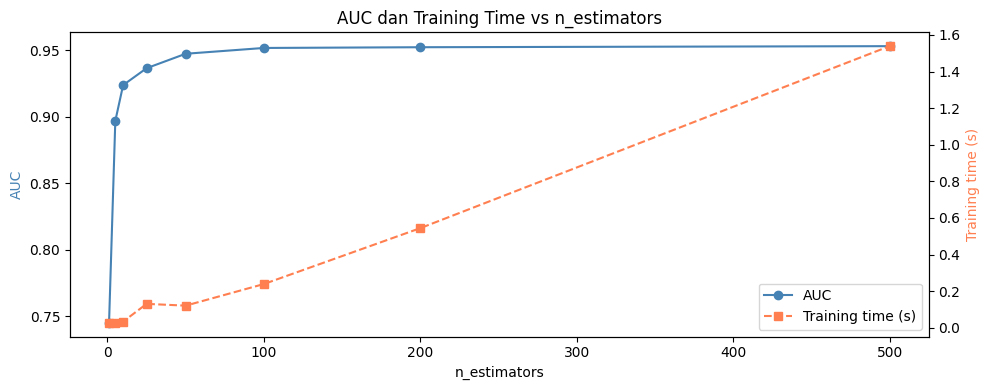

In [11]:
# Plot AUC vs n_estimators
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.plot(df_results["n_estimators"], df_results["auc"],
         "o-", color="steelblue", label="AUC")
ax2.plot(df_results["n_estimators"], df_results["time_s"],
         "s--", color="coral", label="Training time (s)")

ax1.set_xlabel("n_estimators")
ax1.set_ylabel("AUC", color="steelblue")
ax2.set_ylabel("Training time (s)", color="coral")
ax1.set_title("AUC dan Training Time vs n_estimators")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.tight_layout()
plt.show()

Berapa train accuracy Decision Tree vs Random Forest? Apa yang bisa kamu simpulkan dari selisihnya?
-> Decision Tree | Train acc: 1.000 | Test acc: 0.797 | AUC: 0.797 , Random Forest | Train acc: 1.000 | Test acc: 0.890 | AUC: 0.952
Di angka n_estimators berapa AUC mulai tidak naik signifikan? Berapa training time-nya di titik itu?
-> 0,95 pada training time 100

In [12]:
# Task 2: Cek apakah RF berhasil menemukan fitur yang benar-benar informative

# Ingat: kita bikin data dengan n_informative=8 dari 15 fitur
# Artinya feature_00 sampai feature_07 = informative (biasanya, tergantung make_classification)
# feature_08 sampai feature_14 = redundant/noise

# Ambil top-8 fitur menurut RF
top8 = fi_series.head(8).index.tolist()
print("Top 8 fitur menurut RF:")
for i, f in enumerate(top8, 1):
    print(f"  {i}. {f}  (importance: {fi_series[f]:.4f})")

# Hitung berapa dari top-8 yang masuk ke 8 fitur pertama (informative)
# make_classification biasanya menempatkan informative features di index pertama
informative_features = [f"feature_{i:02d}" for i in range(8)]
overlap = set(top8) & set(informative_features)
print(f"\nOverlap dengan fitur informative: {len(overlap)}/8")
print(f"Fitur informative yang terdeteksi: {sorted(overlap)}")

Top 8 fitur menurut RF:
  1. feature_11  (importance: 0.0976)
  2. feature_05  (importance: 0.0926)
  3. feature_09  (importance: 0.0925)
  4. feature_10  (importance: 0.0899)
  5. feature_07  (importance: 0.0895)
  6. feature_00  (importance: 0.0777)
  7. feature_08  (importance: 0.0738)
  8. feature_02  (importance: 0.0643)

Overlap dengan fitur informative: 4/8
Fitur informative yang terdeteksi: ['feature_00', 'feature_02', 'feature_05', 'feature_07']


Berapa overlap yang didapat? Apakah RF berhasil menemukan semua 8 fitur informative?
-> overlap yang didapat adalah 4 dari 8. Random Forest menemukan 4 fitur yaitu ['feature_00', 'feature_02', 'feature_05', 'feature_07'] yang informative

In [20]:
# Task 3: Bandingkan RF dengan max_depth berbeda

depth_configs = {
    "No limit (default)": None,
    "max_depth=3":        3,
    "max_depth=5":        5,
    "max_depth=10":       10,
}

print(f"{'Config':<22} {'Train Acc':>10} {'Test Acc':>10} {'AUC':>8} {'Selisih Train & Test':>10}")
print("-" * 80)

for label, depth in depth_configs.items():
    m = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
    m.fit(X_train, y_train)
    tr = m.score(X_train, y_train)
    te = m.score(X_test, y_test)
    au = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    selisih = tr-te
    print(f"{label:<22} {tr:>10.3f} {te:>10.3f} {au:>8.3f} {selisih:>8.3f}")

Config                  Train Acc   Test Acc      AUC Selisih Train & Test
--------------------------------------------------------------------------------
No limit (default)          1.000      0.890    0.952    0.110
max_depth=3                 0.792      0.780    0.855    0.012
max_depth=5                 0.862      0.823    0.904    0.039
max_depth=10                0.984      0.875    0.946    0.109
